In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
df = pd.read_csv("/content/sample_data/global_air_quality_data_10000.csv")
df.head()

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         10000 non-null  object 
 1   Country      10000 non-null  object 
 2   Date         10000 non-null  object 
 3   PM2.5        10000 non-null  float64
 4   PM10         10000 non-null  float64
 5   NO2          10000 non-null  float64
 6   SO2          10000 non-null  float64
 7   CO           10000 non-null  float64
 8   O3           10000 non-null  float64
 9   Temperature  10000 non-null  float64
 10  Humidity     10000 non-null  float64
 11  Wind Speed   10000 non-null  float64
dtypes: float64(9), object(3)
memory usage: 937.6+ KB
None


In [8]:
print(df.isnull().sum())
df = df.fillna(df.mean(numeric_only=True))

City           0
Country        0
Date           0
PM2.5          0
PM10           0
NO2            0
SO2            0
CO             0
O3             0
Temperature    0
Humidity       0
Wind Speed     0
dtype: int64


In [9]:
numeric_cols = df.select_dtypes(include=np.number)

print(numeric_cols.head())

    PM2.5    PM10    NO2    SO2    CO      O3  Temperature  Humidity  \
0   86.57   25.19  99.88  30.63  4.46   36.29        17.67     59.35   
1   50.63   97.39  48.14   8.71  3.40  144.16         3.46     67.51   
2  130.21   57.22  98.51   9.92  0.12  179.31        25.29     29.30   
3  119.70  130.52  10.96  33.03  7.74   38.65        23.15     99.97   
4   55.20   36.62  76.85  21.85  2.00   67.09        16.02     90.28   

   Wind Speed  
0       13.76  
1        6.36  
2       12.87  
3        7.71  
4       14.16  


In [11]:
df['AQI'] = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].mean(axis=1)

X = df[['PM2.5',
        'CO',
        'NO2',
        'O3']]
y = df['AQI']

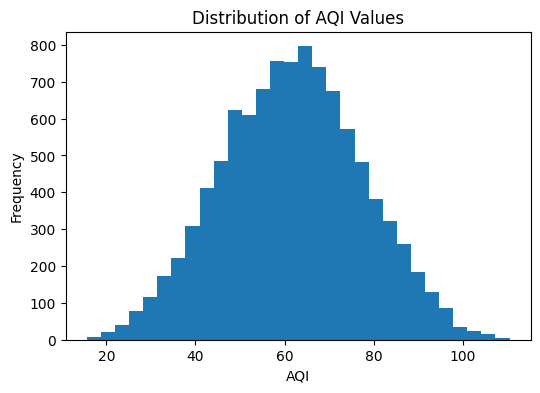

In [13]:
plt.figure(figsize=(6,4))

plt.hist(df['AQI'], bins=30)

plt.title("Distribution of AQI Values")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

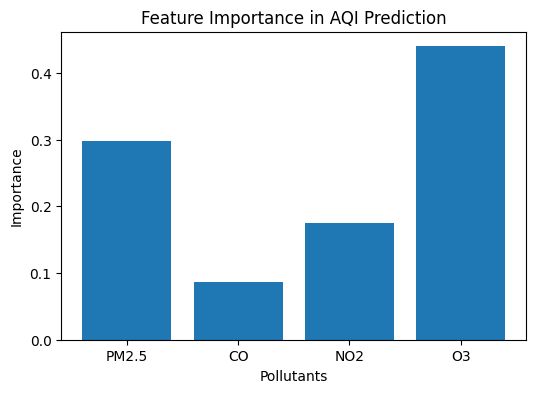

In [18]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(6,4))

plt.bar(features, importance)

plt.title("Feature Importance in AQI Prediction")
plt.xlabel("Pollutants")
plt.ylabel("Importance")

plt.show()

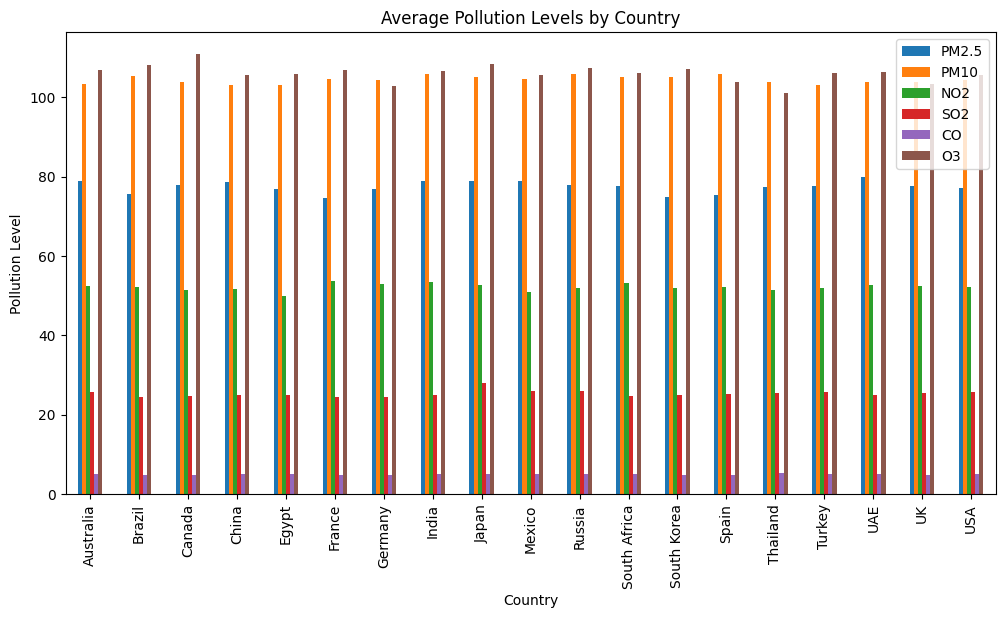

In [ ]:
country_pollution = df.groupby('Country')[['PM2.5','PM10','NO2','SO2','CO','O3']].mean()

country_pollution.plot(kind='bar', figsize=(12,6))
plt.title("Average Pollution Levels by Country")
plt.xlabel("Country")
plt.ylabel("Pollution Level")
plt.show()

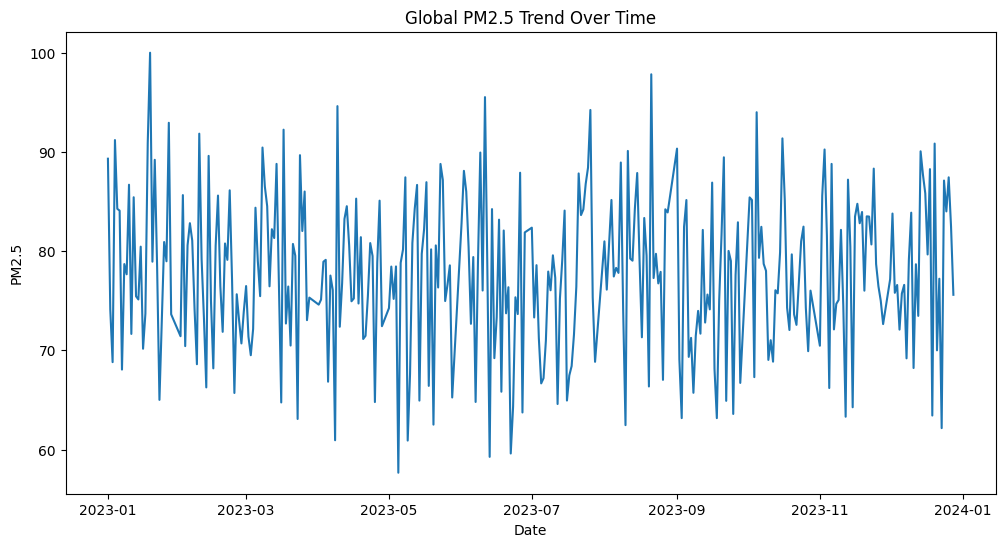

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

daily_pollution = df.groupby('Date')['PM2.5'].mean()

plt.figure(figsize=(12,6))
plt.plot(daily_pollution)
plt.title("Global PM2.5 Trend Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.show()

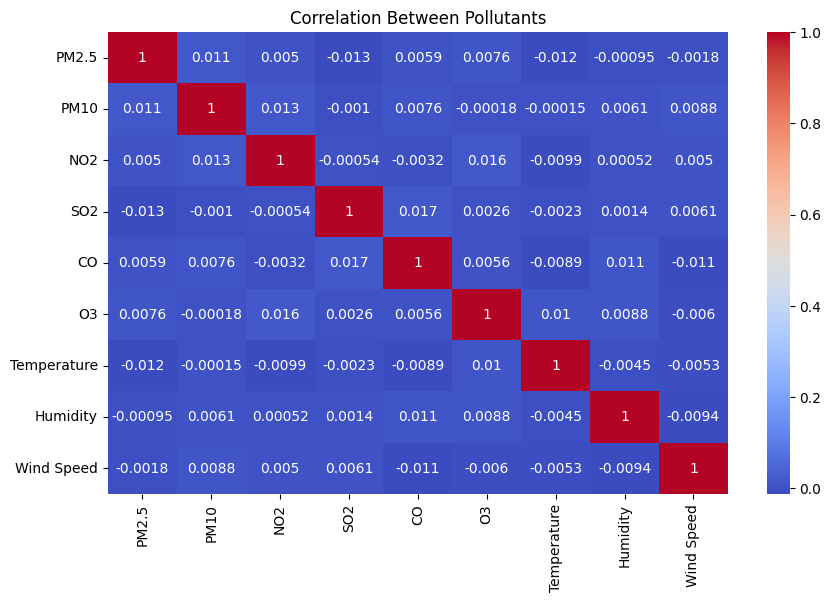

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Between Pollutants")

plt.show()

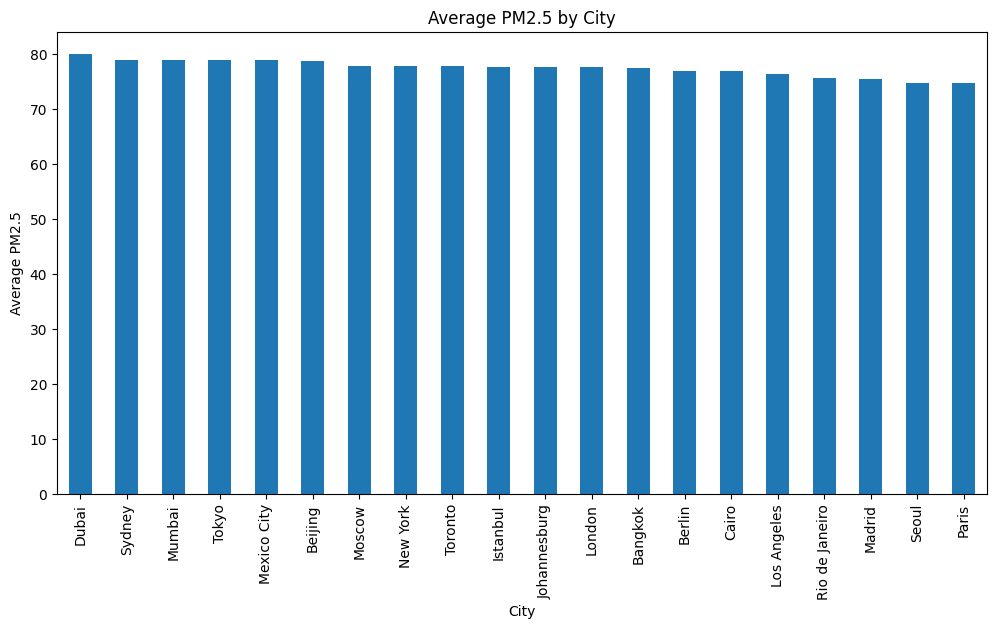

In [ ]:
city_aqi = df.groupby('City')['PM2.5'].mean().sort_values(ascending=False)

city_aqi.plot(kind='bar', figsize=(12,6))
plt.title("Average PM2.5 by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5")
plt.show()

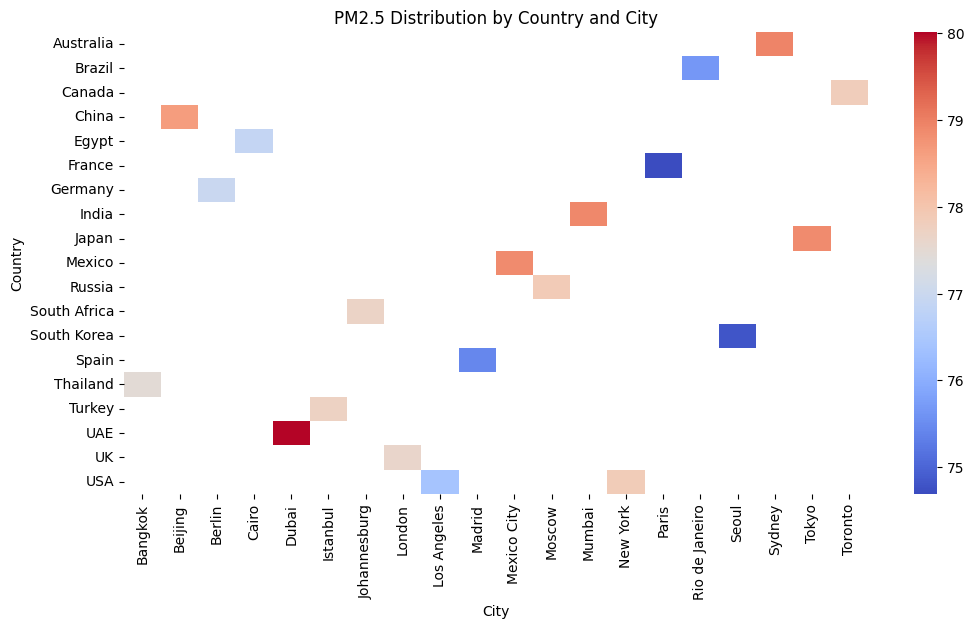

In [ ]:
pivot = df.pivot_table(values='PM2.5', index='Country', columns='City')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("PM2.5 Distribution by Country and City")
plt.show()

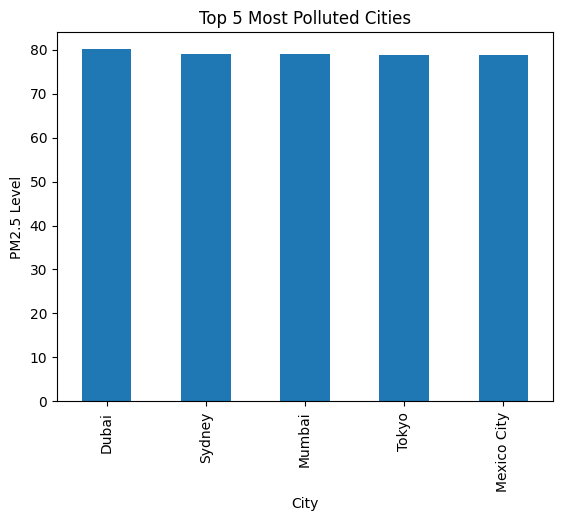

In [ ]:
top_cities = df.groupby('City')['PM2.5'].mean().nlargest(5)

top_cities.plot(kind='bar')
plt.title("Top 5 Most Polluted Cities")
plt.ylabel("PM2.5 Level")
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [21]:
predictions = model.predict(X_test)

print("Predicted AQI values:")
print(predictions[:10])

Predicted AQI values:
[51.59383333 51.1988     45.36646667 62.26921667 54.62105    43.29626667
 71.48573333 44.8851     62.88378333 41.05373333]


In [22]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 8.595152775
R2 Score: 0.5749685147304657


In [23]:
new_data = [[150, 120, 80, 100]]

predicted_aqi = model.predict(new_data)

print("Predicted AQI:", predicted_aqi)

Predicted AQI: [76.7806]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
